# CATBOOST DIRECT MULTI-HORIZON FORECASTING

Цель — изолированно проверить прирост от CatBoost на тех же 15 causal-признаках, temporal split и test origins. Прогнозируется полный vector `[T+1, T+2, T+3, T+4, T+5]`, где горизонт измеряется quote observations.

## 1. Existing artifacts

EDA, stationarity, feature engineering, ARIMA/ARIMAX и baseline training не повторяются. Загружаются результаты предыдущего direct experiment, feature dictionary, фактическая feature schema и сохранённый split.

In [1]:
from pathlib import Path
import sys
import catboost
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
if not (ROOT / 'src').exists(): raise RuntimeError('Не найден корень репозитория')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from src.catboost_multihorizon import plot_representative, predict_next_5_rates, run_catboost_multihorizon

required = [
 'notebooks/03_direct_multihorizon_forecasting.ipynb',
 'reports/direct_multihorizon_results.csv',
 'reports/direct_multihorizon_test_predictions.csv',
 'docs/base_feature_dictionary.md',
 'data/features/fx_features_daily.parquet',
 'reports/temporal_split_horizons.csv',
]
inventory = pd.DataFrame({'artifact': required, 'exists': [(ROOT/p).exists() for p in required]})
display(inventory)
if not inventory.exists.all(): raise FileNotFoundError(inventory.loc[~inventory.exists,'artifact'].tolist())
print('CatBoost:', catboost.__version__)

,artifact,exists
0,notebooks/03_direct_multihorizon_forecasting.i...,True
1,reports/direct_multihorizon_results.csv,True
2,reports/direct_multihorizon_test_predictions.csv,True
3,docs/base_feature_dictionary.md,True
4,data/features/fx_features_daily.parquet,True
5,reports/temporal_split_horizons.csv,True


CatBoost: 1.2.10


## 2. Task, targets и leakage protocol

Для каждого `corridor × horizon` обучается отдельный `CatBoostRegressor`. Все пять моделей получают только один и тот же $X_T$; H1 prediction не входит в H2. Target: $\log(P_{T+h}/P_T)$, после prediction курс восстанавливается как $P_T\exp(\hat y_h)$. Последние пять right-censored origin исключены.

**TEST LOCKED.** Random split, future features и test-based selection запрещены.

In [2]:
run = run_catboost_multihorizon(ROOT, make_plots=False)
print('Status:', run['status'])
print('Dataset:', run['dataset_path'].relative_to(ROOT))
print('Rows:', len(run['frame']), 'Test predictions:', len(run['predictions']))

Status: PASS
Dataset: data\features\fx_features_daily.parquet
Rows: 9445 Test predictions: 1375


## 3. Exact same causal feature set

Feature space намеренно не расширяется: сравнивается изменение модели, а не одновременно модели и данных. Audit повторно проверяет availability at T, duplicates, variance и correlation только на TRAIN.

In [3]:
print('Final feature list:', len(run['features']))
for feature in run['features']: print('-', feature)
display(run['feature_audit'])

Final feature list: 15
- ret_1
- ret_3
- ret_5
- vol_5
- vol_20
- dist_min_20
- favourability_percentile_90
- dist_sma_20
- broad_rub_return_1
- broad_rub_return_3
- broad_rub_return_5
- corridor_specific_return_1
- return_sign_reversal_up
- reversal_strength
- near_min_reversal_010


,feature,available_at_t,reason,used,train_missing_share,train_variance,exact_duplicate_of,correlated_with,correlation
0,ret_1,True,causal trailing/as-of feature documented in re...,True,0.000756,0.000191,,,NaN
1,ret_3,True,causal trailing/as-of feature documented in re...,True,0.002269,0.000644,,,NaN
2,ret_5,True,causal trailing/as-of feature documented in re...,True,0.003782,0.001134,,,NaN
3,vol_5,True,causal trailing/as-of feature documented in re...,True,0.003782,0.000105,,,NaN
4,vol_20,True,causal trailing/as-of feature documented in re...,True,0.015129,0.000088,,,NaN
5,dist_min_20,True,causal trailing/as-of feature documented in re...,True,0.014372,0.002602,,,NaN
6,favourability_percentile_90,True,causal trailing/as-of feature documented in re...,True,0.068079,0.125108,,,NaN
7,dist_sma_20,True,causal trailing/as-of feature documented in re...,True,0.014372,0.001494,,,NaN
8,broad_rub_return_1,True,causal trailing/as-of feature documented in re...,True,0.000756,0.000162,,,NaN
9,broad_rub_return_3,True,causal trailing/as-of feature documented in re...,True,0.002269,0.000620,,,NaN


## 4. Same temporal split и purge

Используются границы предыдущего direct experiment: 274 validation origins и 275 test origins на коридор. Между origin partitions сохраняется purge не менее пяти quote observations. Warm-up NaN удаляются complete-case способом без backward fill.

In [4]:
display(run['splits'])
display(run['partition_audit'])

,corridor,train_start,train_end,validation_start,validation_end,test_start,test_end,n_train,n_validation,n_test,validation_origin_start,validation_origin_end,test_origin_start,test_origin_end,n_validation_origins,n_test_origins,n_right_censored_origins,forecast_horizons,primary_horizon,max_horizon
0,AMD_RUB,2019-01-10,2024-05-23,2024-05-24,2025-07-12,2025-07-15,2026-09-03,1322,283,284,2024-05-23,2025-06-28,2025-07-12,2026-08-20,274,275,10,"1,3,5,10",5,10
1,KGS_RUB,2019-01-10,2024-05-23,2024-05-24,2025-07-12,2025-07-15,2026-09-03,1322,283,284,2024-05-23,2025-06-28,2025-07-12,2026-08-20,274,275,10,"1,3,5,10",5,10
2,KZT_RUB,2019-01-10,2024-05-23,2024-05-24,2025-07-12,2025-07-15,2026-09-03,1322,283,284,2024-05-23,2025-06-28,2025-07-12,2026-08-20,274,275,10,"1,3,5,10",5,10
3,TJS_RUB,2019-01-10,2024-05-23,2024-05-24,2025-07-12,2025-07-15,2026-09-03,1322,283,284,2024-05-23,2025-06-28,2025-07-12,2026-08-20,274,275,10,"1,3,5,10",5,10
4,UZS_RUB,2019-01-10,2024-05-23,2024-05-24,2025-07-12,2025-07-15,2026-09-03,1322,283,284,2024-05-23,2025-06-28,2025-07-12,2026-08-20,274,275,10,"1,3,5,10",5,10


,corridor,partition,rows_before_complete_case,rows_after_complete_case,rows_lost,start,end,train_validation_purge_observations,validation_test_purge_observations
0,AMD_RUB,train,1317,1227,90,2019-05-24,2024-05-16,5,10
1,AMD_RUB,validation,274,274,0,2024-05-23,2025-06-28,5,10
2,AMD_RUB,refit,1600,1510,90,2019-05-24,2025-07-05,5,10
3,AMD_RUB,test,275,275,0,2025-07-12,2026-08-20,5,10
4,KGS_RUB,train,1317,1227,90,2019-05-24,2024-05-16,5,10
5,KGS_RUB,validation,274,274,0,2024-05-23,2025-06-28,5,10
6,KGS_RUB,refit,1600,1510,90,2019-05-24,2025-07-05,5,10
7,KGS_RUB,test,275,275,0,2025-07-12,2026-08-20,5,10
8,KZT_RUB,train,1317,1227,90,2019-05-24,2024-05-16,5,10
9,KZT_RUB,validation,274,274,0,2024-05-23,2025-06-28,5,10


## 5. Controlled configurations и early stopping

Проверяются ровно четыре заданные configurations. На каждом `corridor × horizon` early stopping использует только validation (`50` rounds). Selection: minimum validation MAE в rate space, затем RMSE. `best_iteration` фиксируется; финальный refit на TRAIN+VALIDATION не использует test.

In [5]:
print('Candidate fits:', len(run['candidates']))
display(run['selections'][['corridor','horizon','config_id','params','best_iteration','trees_used','MAE','RMSE','DA']])

Candidate fits: 100


,corridor,horizon,config_id,params,best_iteration,trees_used,MAE,RMSE,DA
0,AMD_RUB,1,CONFIG_2,"{""depth"": 4, ""iterations"": 500, ""l2_leaf_reg"":...",107,108,0.001657,0.002426,0.540146
1,AMD_RUB,2,CONFIG_3,"{""depth"": 6, ""iterations"": 300, ""l2_leaf_reg"":...",66,67,0.002690,0.003821,0.540146
2,AMD_RUB,3,CONFIG_3,"{""depth"": 6, ""iterations"": 300, ""l2_leaf_reg"":...",32,33,0.003360,0.004776,0.463504
3,AMD_RUB,4,CONFIG_1,"{""depth"": 4, ""iterations"": 300, ""l2_leaf_reg"":...",30,31,0.003824,0.005451,0.492701
4,AMD_RUB,5,CONFIG_3,"{""depth"": 6, ""iterations"": 300, ""l2_leaf_reg"":...",10,11,0.004214,0.006092,0.489051
5,KGS_RUB,1,CONFIG_4,"{""depth"": 6, ""iterations"": 500, ""l2_leaf_reg"":...",497,498,0.007380,0.010874,0.613139
6,KGS_RUB,2,CONFIG_2,"{""depth"": 4, ""iterations"": 500, ""l2_leaf_reg"":...",12,13,0.011909,0.017170,0.478102
7,KGS_RUB,3,CONFIG_4,"{""depth"": 6, ""iterations"": 500, ""l2_leaf_reg"":...",23,24,0.014790,0.020927,0.474453
8,KGS_RUB,4,CONFIG_1,"{""depth"": 4, ""iterations"": 300, ""l2_leaf_reg"":...",3,4,0.016672,0.023769,0.474453
9,KGS_RUB,5,CONFIG_4,"{""depth"": 6, ""iterations"": 500, ""l2_leaf_reg"":...",5,6,0.018134,0.026356,0.485401


## 6. Unified five-element forecast vector

In [6]:
corridor = sorted(run['models'])[0]
row = run['partitions'][corridor]['test'].iloc[0]
print(corridor, row.date.date())
print(predict_next_5_rates(row, corridor, run['models'], run['features']))

AMD_RUB 2025-07-12
[0.20285273508814827, 0.20268644757504953, 0.2028471232874214, 0.20299383412229677, 0.20303145021775984]


## 7. Locked-test predictions и metrics

Metrics рассчитаны в rate space: MAE/RMSE/DA отдельно H1...H5, Path MAE по всей траектории, Future-Best MAE и Regret MAE. Actual regret используется только для evaluation.

In [7]:
required_columns = ['corridor','date','rate_t', *[f'actual_rate_h{h}' for h in range(1,6)], *[f'predicted_rate_h{h}' for h in range(1,6)], 'actual_future_best_5','predicted_future_best_5','actual_regret_5','predicted_regret_5']
display(run['predictions'][required_columns].head())
display(run['results'])

,corridor,date,rate_t,actual_rate_h1,actual_rate_h2,actual_rate_h3,actual_rate_h4,actual_rate_h5,predicted_rate_h1,predicted_rate_h2,predicted_rate_h3,predicted_rate_h4,predicted_rate_h5,actual_future_best_5,predicted_future_best_5,actual_regret_5,predicted_regret_5
0,AMD_RUB,2025-07-12,0.202874,0.204020,0.202953,0.203038,0.203545,0.203818,0.202853,0.202686,0.202847,0.202994,0.203031,0.202953,0.202686,0.000000,0.000924
1,AMD_RUB,2025-07-15,0.204020,0.202953,0.203038,0.203545,0.203818,0.204068,0.204181,0.204205,0.204233,0.204244,0.204307,0.202953,0.204181,0.005230,0.000000
2,AMD_RUB,2025-07-16,0.202953,0.203038,0.203545,0.203818,0.204068,0.203371,0.202754,0.202757,0.203003,0.203110,0.203150,0.203038,0.202754,0.000000,0.000982
3,AMD_RUB,2025-07-17,0.203038,0.203545,0.203818,0.204068,0.203371,0.204344,0.203039,0.203011,0.203045,0.203230,0.203229,0.203371,0.203011,0.000000,0.000132
4,AMD_RUB,2025-07-18,0.203545,0.203818,0.204068,0.203371,0.204344,0.205510,0.203654,0.203685,0.203742,0.203798,0.203870,0.203371,0.203654,0.000855,0.000000


,corridor,model,MAE_H1,RMSE_H1,DA_H1,MAE_H2,RMSE_H2,DA_H2,MAE_H3,RMSE_H3,...,Path_MAE_5_practical_status,Future_Best_MAE_5_ratio_vs_previous_direct,Future_Best_MAE_5_improvement_pct_vs_previous_direct,Future_Best_MAE_5_practical_status,Regret_MAE_5_ratio_vs_previous_direct,Regret_MAE_5_improvement_pct_vs_previous_direct,Regret_MAE_5_practical_status,MAE_H5_ratio_vs_naive,Path_MAE_ratio_vs_naive,Path_MAE_ratio_vs_previous_direct
0,AMD_RUB,CATBOOST,0.001303,0.001737,0.574545,0.001999,0.002642,0.563636,0.002638,0.003366,...,WORSE,1.004302,-0.430242,WORSE,1.005214,-0.521420,WORSE,0.992776,0.985161,1.002704
1,KGS_RUB,CATBOOST,0.005613,0.007482,0.560000,0.008808,0.011581,0.578182,0.011585,0.014726,...,WORSE,1.003724,-0.372386,WORSE,1.012254,-1.225431,WORSE,0.998773,0.995242,1.008239
2,KZT_RUB,CATBOOST,0.001220,0.001630,0.578182,0.001884,0.002430,0.450909,0.002292,0.002972,...,WORSE,1.011885,-1.188534,WORSE,1.013925,-1.392544,WORSE,1.001291,0.999286,1.006304
3,TJS_RUB,CATBOOST,0.054414,0.073596,0.556364,0.084745,0.111129,0.563636,0.111367,0.140271,...,WORSE,1.016497,-1.649693,WORSE,1.043419,-4.341850,WORSE,0.996047,0.991887,1.023831
4,UZS_RUB,CATBOOST,0.000047,0.000060,0.578182,0.000074,0.000095,0.570909,0.000096,0.000120,...,WORSE,1.012306,-1.230608,WORSE,1.018676,-1.867578,WORSE,0.994179,0.992989,1.008253


## 8. Comparison with previous models

Best previous direct reference выбирается между уже готовыми Ridge и Gradient Boosting по H5 MAE. Все ratios рассчитаны на тех же test origins. Сравнение также содержит сохранённые Naive, ARIMA и ARIMAX результаты — без retraining.

In [8]:
display(run['best_previous'][['corridor','previous_direct_model','MAE_H5','Path_MAE_5','Future_Best_MAE_5','Regret_MAE_5']])
comparison_columns = ['corridor','MAE_H5_ratio_vs_previous_direct','MAE_H5_improvement_pct_vs_previous_direct','MAE_H5_practical_status','Path_MAE_ratio_vs_previous_direct','Path_MAE_5_improvement_pct_vs_previous_direct','Path_MAE_5_practical_status','MAE_H5_ratio_vs_naive','Path_MAE_ratio_vs_naive']
display(run['results'][comparison_columns])

,corridor,previous_direct_model,MAE_H5,Path_MAE_5,Future_Best_MAE_5,Regret_MAE_5
0,AMD_RUB,DIRECT_GRADIENT_BOOSTING,0.003436,0.002494,0.002464,0.009775
1,KGS_RUB,DIRECT_GRADIENT_BOOSTING,0.015070,0.010878,0.010829,0.010123
2,KZT_RUB,DIRECT_GRADIENT_BOOSTING,0.002909,0.002176,0.002066,0.010945
3,TJS_RUB,DIRECT_RIDGE,0.140707,0.102723,0.103784,0.010031
4,UZS_RUB,DIRECT_GRADIENT_BOOSTING,0.000118,0.000088,0.000085,0.010860


,corridor,MAE_H5_ratio_vs_previous_direct,MAE_H5_improvement_pct_vs_previous_direct,MAE_H5_practical_status,Path_MAE_ratio_vs_previous_direct,Path_MAE_5_improvement_pct_vs_previous_direct,Path_MAE_5_practical_status,MAE_H5_ratio_vs_naive,Path_MAE_ratio_vs_naive
0,AMD_RUB,1.008828,-0.882850,WORSE,1.002704,-0.270439,WORSE,0.992776,0.985161
1,KGS_RUB,1.010475,-1.047529,WORSE,1.008239,-0.823920,WORSE,0.998773,0.995242
2,KZT_RUB,0.998826,0.117378,PRACTICALLY_TIED,1.006304,-0.630411,WORSE,1.001291,0.999286
3,TJS_RUB,1.032840,-3.283997,WORSE,1.023831,-2.383067,WORSE,0.996047,0.991887
4,UZS_RUB,1.000020,-0.002001,WORSE,1.008253,-0.825274,WORSE,0.994179,0.992989


Practical convention: положительный прирост менее 1% — `PRACTICALLY_TIED`, прирост не менее 1% — `IMPROVED`, ухудшение — `WORSE`. Поэтому микроскопическая разница не объявляется сильным результатом.

## 9. CatBoost feature importance

Importance усредняется по пяти horizon models внутри corridor. Это predictive association, а не causal effect; SHAP не используется.

In [9]:
display(run['importance'].loc[run['importance']['rank'] <= 10])

,corridor,feature,importance,rank
0,AMD_RUB,vol_20,24.631920,1
1,AMD_RUB,reversal_strength,15.748047,2
2,AMD_RUB,vol_5,7.711286,3
3,AMD_RUB,ret_1,7.323412,4
4,AMD_RUB,broad_rub_return_3,7.078872,5
5,AMD_RUB,favourability_percentile_90,6.259250,6
6,AMD_RUB,broad_rub_return_5,5.959591,7
7,AMD_RUB,broad_rub_return_1,5.223994,8
8,AMD_RUB,corridor_specific_return_1,4.675275,9
9,AMD_RUB,dist_sma_20,4.453840,10


## 10. Minimal visualization

Ровно один representative origin на corridor: actual, CatBoost, лучшая previous direct model и Naive.

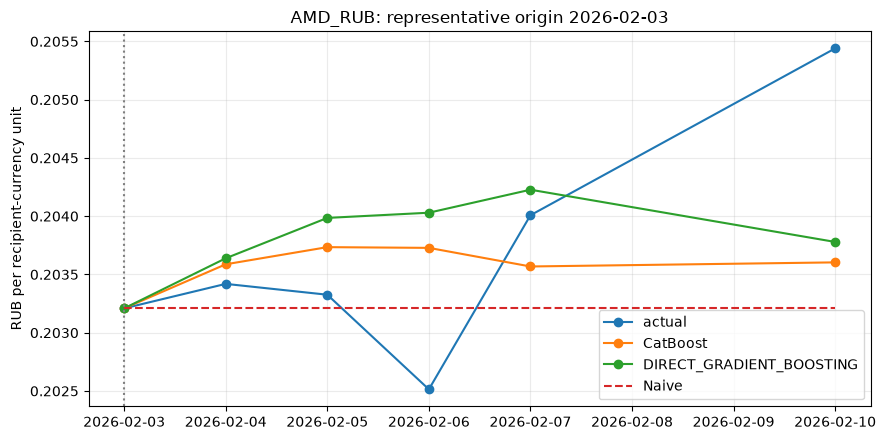

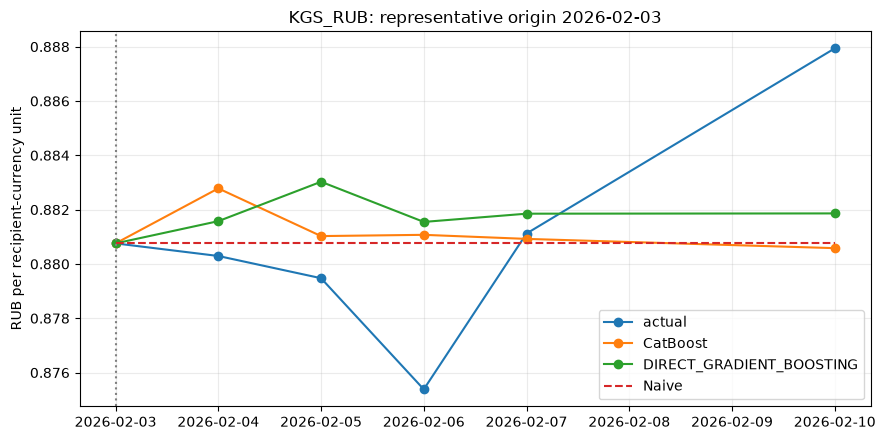

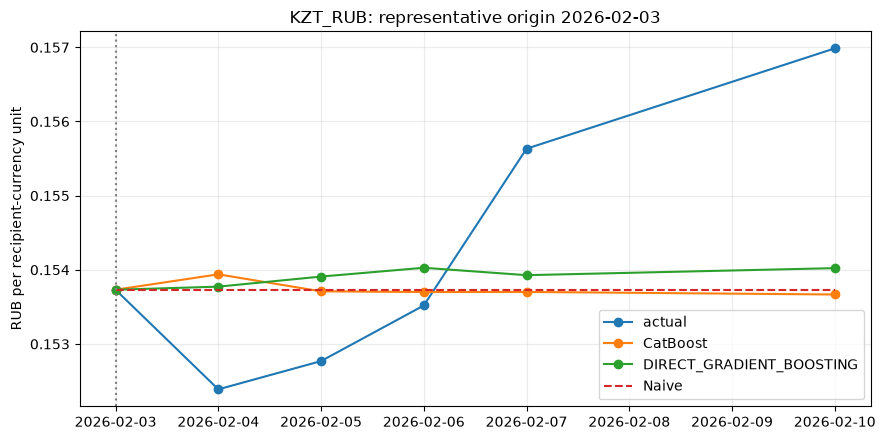

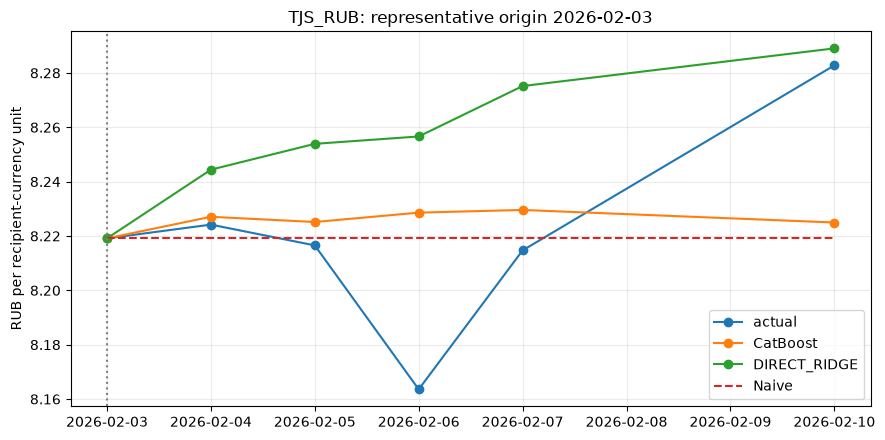

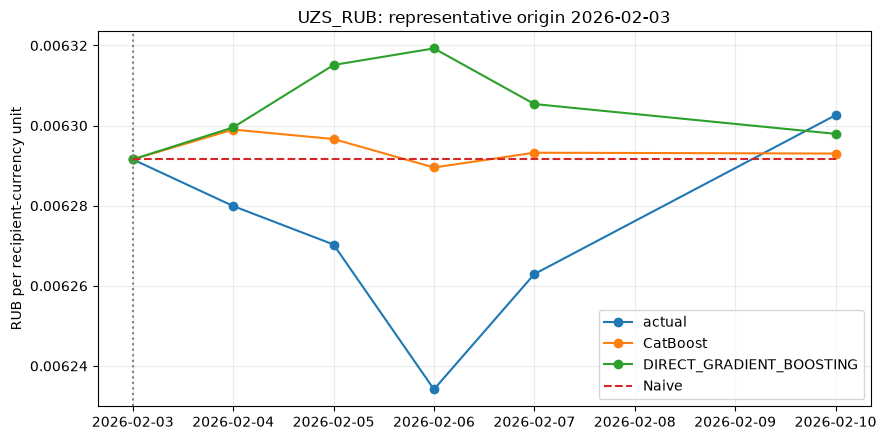

In [10]:
plot_representative(run['predictions'], run['previous_predictions'], run['best_previous'])

## 11. Leakage check

In [11]:
display(run['leakage'])
leakage_status = 'PASS' if run['leakage'].passed.all() else 'FAIL'
print('CATBOOST MULTIHORIZON LEAKAGE CHECK:', leakage_status)

,check,passed
0,same temporal split as previous experiment,True
1,same test origins,True
2,all X available at T,True
3,no actual T+1...T+5 used in X,True
4,no future-derived features,True
5,validation-only tuning,True
6,test locked,True
7,purge >= 5,True
8,targets only used as y,True
9,no test-based feature selection,True


CATBOOST MULTIHORIZON LEAKAGE CHECK: PASS


## 12. Final summary

In [12]:
r = run['results']
best = r.sort_values('MAE_H5_improvement_pct_vs_previous_direct', ascending=False).iloc[0]
worst = r.sort_values('MAE_H5_improvement_pct_vs_previous_direct').iloc[0]
print('CATBOOST MULTIHORIZON:', run['status'])
print(f"CatBoost beats previous direct model on MAE_H5: {(r.MAE_H5_ratio_vs_previous_direct < 1).sum()} / 5 corridors")
print(f"CatBoost beats previous direct model on Path_MAE_5: {(r.Path_MAE_ratio_vs_previous_direct < 1).sum()} / 5")
print(f"CatBoost beats Naive on MAE_H5: {(r.MAE_H5_ratio_vs_naive < 1).sum()} / 5")
print(f"CatBoost beats Naive on Path_MAE_5: {(r.Path_MAE_ratio_vs_naive < 1).sum()} / 5")
print(f"Best H5 improvement vs previous direct: {best.corridor}, {best.MAE_H5_improvement_pct_vs_previous_direct:.3f}%, {best.MAE_H5_practical_status}")
print(f"Worst H5 result: {worst.corridor}, {worst.MAE_H5_improvement_pct_vs_previous_direct:.3f}%, {worst.MAE_H5_practical_status}")
print('Future-Best statuses:', r.set_index('corridor').Future_Best_MAE_5_practical_status.to_dict())
print('Regret statuses:', r.set_index('corridor').Regret_MAE_5_practical_status.to_dict())
print('Leakage:', leakage_status)
print('Files:')
print('notebooks/04_catboost_multihorizon_forecasting.ipynb')
for key in ('predictions','results','report'): print(run['outputs'][key].relative_to(ROOT).as_posix())

CATBOOST MULTIHORIZON: PASS
CatBoost beats previous direct model on MAE_H5: 1 / 5 corridors
CatBoost beats previous direct model on Path_MAE_5: 0 / 5
CatBoost beats Naive on MAE_H5: 4 / 5
CatBoost beats Naive on Path_MAE_5: 5 / 5
Best H5 improvement vs previous direct: KZT_RUB, 0.117%, PRACTICALLY_TIED
Worst H5 result: TJS_RUB, -3.284%, WORSE
Future-Best statuses: {'AMD_RUB': 'WORSE', 'KGS_RUB': 'WORSE', 'KZT_RUB': 'WORSE', 'TJS_RUB': 'WORSE', 'UZS_RUB': 'WORSE'}
Regret statuses: {'AMD_RUB': 'WORSE', 'KGS_RUB': 'WORSE', 'KZT_RUB': 'WORSE', 'TJS_RUB': 'WORSE', 'UZS_RUB': 'WORSE'}
Leakage: PASS
Files:
notebooks/04_catboost_multihorizon_forecasting.ipynb
reports/catboost_multihorizon_test_predictions.csv
reports/catboost_multihorizon_results.csv
reports/catboost_multihorizon_report.md
